# Predictive Modeling (AML + DL) with Explainability

## Goal
Predict `deal_stage` (`target`: Won/Lost) with a focused and defensible workflow that covers:
1. **Baseline ML**: Logistic Regression
2. **Advanced ML**: SVM (RBF)
3. **Primary DL**: Custom **Dual-Path MLP** for heterogeneous tabular data

## Scope Control
- Keep only essential models aligned with course objectives.
- Prioritize F1, ROC AUC, precision, recall, and failure analysis.
- Add explainability and first-principles theory support for submission rigor.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings('ignore')
os.makedirs('../results', exist_ok=True)

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

print(f'SHAP available: {SHAP_AVAILABLE}')

SHAP available: True


## 1. Heterogeneous Data + Preprocessing + Regularization Rationale
The dataset is heterogeneous: **numeric + categorical** fields, so one preprocessing strategy is not enough.

### Why preprocessing is necessary
- **Numeric scaling (`StandardScaler`)** stabilizes optimization and prevents large-range features from dominating gradients.
- **Categorical encoding (`OneHotEncoder`)** transforms symbolic variables into machine-readable sparse/dense indicators.
- **Log transforms (`log_revenue`, `log_employees`)** reduce skew and stabilize heavy-tailed distributions.

### Why regularization is needed
- **L2 regularization (`alpha`)** discourages excessively large weights and improves generalization.
- **Dropout concept**: not used here, but conceptually similar goal (reduce co-adaptation/overfitting).

In [2]:
try:
    df = pd.read_csv('../data/processed/processed_sales_data.csv')
except FileNotFoundError:
    df = pd.read_csv('data/processed/processed_sales_data.csv')

features = [
    'sector', 'year_established', 'revenue', 'employees', 'office_location',
    'series', 'sales_price', 'product', 'manager', 'regional_office',
    'engage_year', 'engage_month', 'log_revenue', 'log_employees'
]
target = 'target'

categorical_features = ['sector', 'office_location', 'series', 'product', 'manager', 'regional_office']
numeric_features = ['year_established', 'revenue', 'employees', 'sales_price', 'engage_year', 'engage_month', 'log_revenue', 'log_employees']

df = df.dropna(subset=features + [target]).copy()
X = df[features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_scaler = StandardScaler()
cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_num_train = num_scaler.fit_transform(X_train[numeric_features])
X_num_test = num_scaler.transform(X_test[numeric_features])

X_cat_train = cat_encoder.fit_transform(X_train[categorical_features])
X_cat_test = cat_encoder.transform(X_test[categorical_features])

X_train_processed = np.hstack([X_num_train, X_cat_train])
X_test_processed = np.hstack([X_num_test, X_cat_test])
feature_names = numeric_features + list(cat_encoder.get_feature_names_out(categorical_features))

print(f'Loaded data shape: {df.shape}')
print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')
print('Target balance in train (normalized):')
print(y_train.value_counts(normalize=True).sort_index())
print('Heterogeneous feature counts:')
print(f'- Numeric features: {len(numeric_features)}')
print(f'- Encoded categorical features: {X_cat_train.shape[1]}')

Loaded data shape: (6711, 27)
Train shape: (5368, 14) | Test shape: (1343, 14)
Target balance in train (normalized):
target
0    0.36848
1    0.63152
Name: proportion, dtype: float64
Heterogeneous feature counts:
- Numeric features: 8
- Encoded categorical features: 45


## 2. Baseline ML + AML Models
- **Baseline**: Logistic Regression (`class_weight='balanced'`)
- **AML**: SVM with RBF kernel (`class_weight='balanced'`, minimal tuning)

These models provide conceptual coverage and benchmarking before the custom DL model.

In [3]:
models = {
    'Logistic Regression (Baseline)': Pipeline(
        steps=[
            ('preprocessor', ColumnTransformer(
                transformers=[
                    ('num', StandardScaler(), numeric_features),
                    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
                ]
            )),
            ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
        ]
    ),
    'SVM (RBF)': Pipeline(
        steps=[
            ('preprocessor', ColumnTransformer(
                transformers=[
                    ('num', StandardScaler(), numeric_features),
                    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
                ]
            )),
            ('classifier', SVC(
                kernel='rbf',
                C=1.0,
                gamma='scale',
                class_weight='balanced',
                probability=True,
                random_state=42,
            )),
        ]
    ),
}

model_tags = {
    'Logistic Regression (Baseline)': 'baseline_ml_logistic_regression',
    'SVM (RBF)': 'aml_svm_rbf',
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_model = model.predict(X_test)
    y_prob_model = model.predict_proba(X_test)[:, 1]

    row = {
        'Model': name,
        'F1': f1_score(y_test, y_pred_model),
        'Precision': precision_score(y_test, y_pred_model),
        'Recall': recall_score(y_test, y_pred_model),
        'ROC_AUC': roc_auc_score(y_test, y_prob_model),
    }
    results.append(row)
    trained_models[name] = model

    tag = model_tags[name]
    cm_model = confusion_matrix(y_test, y_pred_model)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_model, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'../results/confusion_matrix_{tag}.png', bbox_inches='tight')
    plt.close()

    with open(f'../results/classification_report_{tag}.txt', 'w') as report_file:
        report_file.write(f'Model: {name}\n')
        report_file.write(classification_report(y_test, y_pred_model, digits=4))

print('Baseline/AML models trained.')

Baseline/AML models trained.


## 3. Primary DL Architecture: Dual-Path MLP (Custom Block)
We explicitly encode an **inductive bias** for heterogeneous data:

- Numeric and categorical features are processed through **separate dense paths** first.
- Their learned representations are **concatenated (fusion)**.
- Fused representation goes through final dense layers for binary prediction.

This architecture assumes numeric and categorical patterns are structurally different and should be learned differently before interaction modeling.

In [4]:
class DualPathMLP:
    def __init__(
        self,
        num_input_dim,
        cat_input_dim,
        num_hidden=16,
        cat_hidden=32,
        fusion_hidden=(64, 32),
        alpha=0.001,
        learning_rate=0.001,
        epochs=350,
        batch_size=128,
        patience=20,
        random_state=42,
    ):
        self.num_input_dim = num_input_dim
        self.cat_input_dim = cat_input_dim
        self.num_hidden = num_hidden
        self.cat_hidden = cat_hidden
        self.fusion_hidden = fusion_hidden
        self.alpha = alpha
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.patience = patience
        self.rng = np.random.default_rng(random_state)
        self.history_ = []

    def _he(self, fan_in, fan_out):
        return self.rng.normal(0.0, np.sqrt(2.0 / fan_in), size=(fan_in, fan_out))

    def _init_params(self):
        h1, h2 = self.fusion_hidden
        self.params = {
            'W_num': self._he(self.num_input_dim, self.num_hidden),
            'b_num': np.zeros((1, self.num_hidden)),
            'W_cat': self._he(self.cat_input_dim, self.cat_hidden),
            'b_cat': np.zeros((1, self.cat_hidden)),
            'W_f1': self._he(self.num_hidden + self.cat_hidden, h1),
            'b_f1': np.zeros((1, h1)),
            'W_f2': self._he(h1, h2),
            'b_f2': np.zeros((1, h2)),
            'W_out': self._he(h2, 1),
            'b_out': np.zeros((1, 1)),
        }
        self.m = {k: np.zeros_like(v) for k, v in self.params.items()}
        self.v = {k: np.zeros_like(v) for k, v in self.params.items()}
        self.t = 0

    @staticmethod
    def _relu(x):
        return np.maximum(0.0, x)

    @staticmethod
    def _relu_grad(x):
        return (x > 0.0).astype(float)

    @staticmethod
    def _sigmoid(x):
        x_clip = np.clip(x, -30, 30)
        return 1.0 / (1.0 + np.exp(-x_clip))

    def _forward(self, X_num, X_cat):
        p = self.params

        z_num = X_num @ p['W_num'] + p['b_num']
        a_num = self._relu(z_num)

        z_cat = X_cat @ p['W_cat'] + p['b_cat']
        a_cat = self._relu(z_cat)

        fusion_in = np.concatenate([a_num, a_cat], axis=1)
        z_f1 = fusion_in @ p['W_f1'] + p['b_f1']
        a_f1 = self._relu(z_f1)

        z_f2 = a_f1 @ p['W_f2'] + p['b_f2']
        a_f2 = self._relu(z_f2)

        z_out = a_f2 @ p['W_out'] + p['b_out']
        y_hat = self._sigmoid(z_out)

        cache = {
            'X_num': X_num,
            'X_cat': X_cat,
            'z_num': z_num,
            'a_num': a_num,
            'z_cat': z_cat,
            'a_cat': a_cat,
            'fusion_in': fusion_in,
            'z_f1': z_f1,
            'a_f1': a_f1,
            'z_f2': z_f2,
            'a_f2': a_f2,
            'y_hat': y_hat,
        }
        return y_hat, cache

    def _loss(self, y_true, y_hat):
        eps = 1e-8
        bce = -(y_true * np.log(y_hat + eps) + (1 - y_true) * np.log(1 - y_hat + eps)).mean()
        l2 = 0.5 * self.alpha * (
            np.sum(self.params['W_num'] ** 2)
            + np.sum(self.params['W_cat'] ** 2)
            + np.sum(self.params['W_f1'] ** 2)
            + np.sum(self.params['W_f2'] ** 2)
            + np.sum(self.params['W_out'] ** 2)
        )
        return bce + l2

    def _backward(self, cache, y_true):
        p = self.params
        m = y_true.shape[0]

        y_hat = cache['y_hat']
        dZ_out = (y_hat - y_true) / m

        dW_out = cache['a_f2'].T @ dZ_out + self.alpha * p['W_out']
        db_out = np.sum(dZ_out, axis=0, keepdims=True)

        dA_f2 = dZ_out @ p['W_out'].T
        dZ_f2 = dA_f2 * self._relu_grad(cache['z_f2'])
        dW_f2 = cache['a_f1'].T @ dZ_f2 + self.alpha * p['W_f2']
        db_f2 = np.sum(dZ_f2, axis=0, keepdims=True)

        dA_f1 = dZ_f2 @ p['W_f2'].T
        dZ_f1 = dA_f1 * self._relu_grad(cache['z_f1'])
        dW_f1 = cache['fusion_in'].T @ dZ_f1 + self.alpha * p['W_f1']
        db_f1 = np.sum(dZ_f1, axis=0, keepdims=True)

        dFusion = dZ_f1 @ p['W_f1'].T
        dA_num = dFusion[:, :self.num_hidden]
        dA_cat = dFusion[:, self.num_hidden:]

        dZ_num = dA_num * self._relu_grad(cache['z_num'])
        dW_num = cache['X_num'].T @ dZ_num + self.alpha * p['W_num']
        db_num = np.sum(dZ_num, axis=0, keepdims=True)

        dZ_cat = dA_cat * self._relu_grad(cache['z_cat'])
        dW_cat = cache['X_cat'].T @ dZ_cat + self.alpha * p['W_cat']
        db_cat = np.sum(dZ_cat, axis=0, keepdims=True)

        grads = {
            'W_num': dW_num,
            'b_num': db_num,
            'W_cat': dW_cat,
            'b_cat': db_cat,
            'W_f1': dW_f1,
            'b_f1': db_f1,
            'W_f2': dW_f2,
            'b_f2': db_f2,
            'W_out': dW_out,
            'b_out': db_out,
        }
        return grads

    def _adam_step(self, grads, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for k in self.params:
            self.m[k] = beta1 * self.m[k] + (1 - beta1) * grads[k]
            self.v[k] = beta2 * self.v[k] + (1 - beta2) * (grads[k] ** 2)

            m_hat = self.m[k] / (1 - beta1 ** self.t)
            v_hat = self.v[k] / (1 - beta2 ** self.t)

            self.params[k] -= self.learning_rate * m_hat / (np.sqrt(v_hat) + eps)

    def fit(self, X_num, X_cat, y, X_num_val=None, X_cat_val=None, y_val=None):
        y = np.asarray(y).reshape(-1, 1)

        if X_num_val is None or X_cat_val is None or y_val is None:
            X_num, X_num_val, X_cat, X_cat_val, y, y_val = train_test_split(
                X_num, X_cat, y, test_size=0.2, random_state=42, stratify=y.ravel()
            )

        y_val = np.asarray(y_val).reshape(-1, 1)
        self._init_params()

        best_val = np.inf
        best_params = {k: v.copy() for k, v in self.params.items()}
        wait = 0

        n = X_num.shape[0]

        for epoch in range(self.epochs):
            idx = self.rng.permutation(n)
            X_num_sh = X_num[idx]
            X_cat_sh = X_cat[idx]
            y_sh = y[idx]

            for start in range(0, n, self.batch_size):
                end = min(start + self.batch_size, n)
                xb_num = X_num_sh[start:end]
                xb_cat = X_cat_sh[start:end]
                yb = y_sh[start:end]

                y_hat, cache = self._forward(xb_num, xb_cat)
                grads = self._backward(cache, yb)
                self._adam_step(grads)

            train_hat, _ = self._forward(X_num, X_cat)
            val_hat, _ = self._forward(X_num_val, X_cat_val)

            train_loss = self._loss(y, train_hat)
            val_loss = self._loss(y_val, val_hat)
            self.history_.append((epoch + 1, float(train_loss), float(val_loss)))

            if val_loss < best_val - 1e-6:
                best_val = val_loss
                best_params = {k: v.copy() for k, v in self.params.items()}
                wait = 0
            else:
                wait += 1
                if wait >= self.patience:
                    break

        self.params = best_params
        return self

    def predict_proba(self, X_num, X_cat):
        y_hat, _ = self._forward(X_num, X_cat)
        return y_hat.ravel()

    def predict(self, X_num, X_cat, threshold=0.5):
        return (self.predict_proba(X_num, X_cat) >= threshold).astype(int)


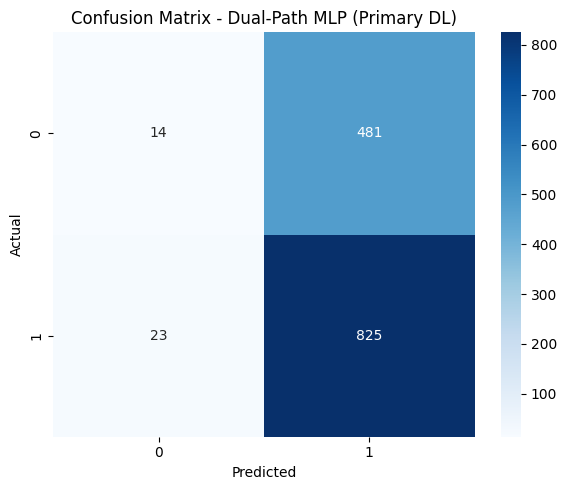

DL threshold: 0.50
F1: 0.7660
Precision: 0.6317
Recall: 0.9729
ROC AUC: 0.5206
Recent training history (epoch, train_loss, val_loss):
    epoch  train_loss  val_loss
41     42    0.649218  0.743414
42     43    0.646612  0.742378
43     44    0.643438  0.742609
44     45    0.647851  0.749131
45     46    0.645190  0.748174
TN=14, FP=481, FN=23, TP=825


In [5]:
# Validation split for controlled convergence monitoring.
X_num_tr, X_num_val, X_cat_tr, X_cat_val, y_tr, y_val = train_test_split(
    X_num_train,
    X_cat_train,
    y_train.values,
    test_size=0.2,
    random_state=42,
    stratify=y_train.values,
)

dual_model = DualPathMLP(
    num_input_dim=X_num_train.shape[1],
    cat_input_dim=X_cat_train.shape[1],
    num_hidden=16,
    cat_hidden=32,
    fusion_hidden=(64, 32),
    alpha=0.001,
    learning_rate=0.001,
    epochs=350,
    batch_size=128,
    patience=20,
    random_state=42,
)

dual_model.fit(X_num_tr, X_cat_tr, y_tr, X_num_val, X_cat_val, y_val)

DL_THRESHOLD = 0.50
y_prob = dual_model.predict_proba(X_num_test, X_cat_test)
y_pred = (y_prob >= DL_THRESHOLD).astype(int)

dl_name = 'Dual-Path MLP (Primary DL)'
trained_models[dl_name] = dual_model

results.append({
    'Model': dl_name,
    'F1': f1_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_prob),
})

threshold_tag = str(DL_THRESHOLD).replace('.', 'p')
cm_dl = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {dl_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(
    f'../results/confusion_matrix_dl_dual_path_mlp_primary_threshold_{threshold_tag}.png',
    bbox_inches='tight',
)
plt.show()

with open('../results/classification_report_dl_dual_path_mlp_primary.txt', 'w') as report_file:
    report_file.write(f'Model: {dl_name}\n')
    report_file.write(f'Decision threshold: {DL_THRESHOLD:.2f}\n')
    report_file.write(classification_report(y_test, y_pred, digits=4))

print(f'DL threshold: {DL_THRESHOLD:.2f}')
print(f'F1: {f1_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'ROC AUC: {roc_auc_score(y_test, y_prob):.4f}')
print('Recent training history (epoch, train_loss, val_loss):')
print(pd.DataFrame(dual_model.history_, columns=['epoch', 'train_loss', 'val_loss']).tail())

tn, fp, fn, tp = cm_dl.ravel()
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')

## 4. Minimal Model Comparison
Comparison is intentionally minimal: **F1 + ROC AUC** with precision/recall context.

In [6]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print('Model comparison (minimal):')
display(results_df)

with open('../results/model_metrics_aml_dl_all_models.txt', 'w') as f:
    f.write('Essential Models (AML + DL)\n')
    f.write(results_df.to_string(index=False))

# Backward-compatible metrics filename.
with open('../results/model_metrics.txt', 'w') as f:
    f.write('Essential Models (AML + DL)\n')
    f.write(results_df.to_string(index=False))

primary_model_name = 'Dual-Path MLP (Primary DL)'
print(f'Primary model for detailed analysis: {primary_model_name}')

Model comparison (minimal):


,Model,F1,Precision,Recall,ROC_AUC
2,Dual-Path MLP (Primary DL),0.766017,0.631700,0.972877,0.520570
1,SVM (RBF),0.517314,0.645503,0.431604,0.488121
0,Logistic Regression (Baseline),0.472782,0.643002,0.373821,0.514007


Primary model for detailed analysis: Dual-Path MLP (Primary DL)


## 5. Validation Check
- Train/test split is retained.
- Optional cross-validation can be enabled for baseline/AML pipelines.
- Custom DL model uses an explicit validation split with early stopping.

In [7]:
RUN_CV = False

if RUN_CV:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for name, model in models.items():
        cv_scores = cross_val_score(model, X, y, cv=cv, scoring='f1', n_jobs=-1)
        print(f'{name} CV F1 scores: {np.round(cv_scores, 4)}')
        print(f'{name} CV F1 mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
else:
    print('Cross-validation skipped (RUN_CV=False).')

Cross-validation skipped (RUN_CV=False).


## 6. Failure Analysis (Primary DL)
- **False Positives**: bad bets (predicted Won, actually Lost)
- **False Negatives**: missed opportunities (predicted Lost, actually Won)

This analysis is the business-facing core: error concentration and high-confidence failure patterns.

Total errors: 504 / 1343
Error distribution by sector:
Result              False Negative (Missed Opp)  False Positive (Bad Bet)
sector                                                                   
employment                                    6                        25
entertainment                                 0                        23
finance                                       2                        41
marketing                                     1                        36
medical                                       2                        74
retail                                        5                        96
services                                      0                        34
software                                      1                        46
technolgy                                     6                        77
telecommunications                            0                        29
Error distribution by product:
Result          False Nega

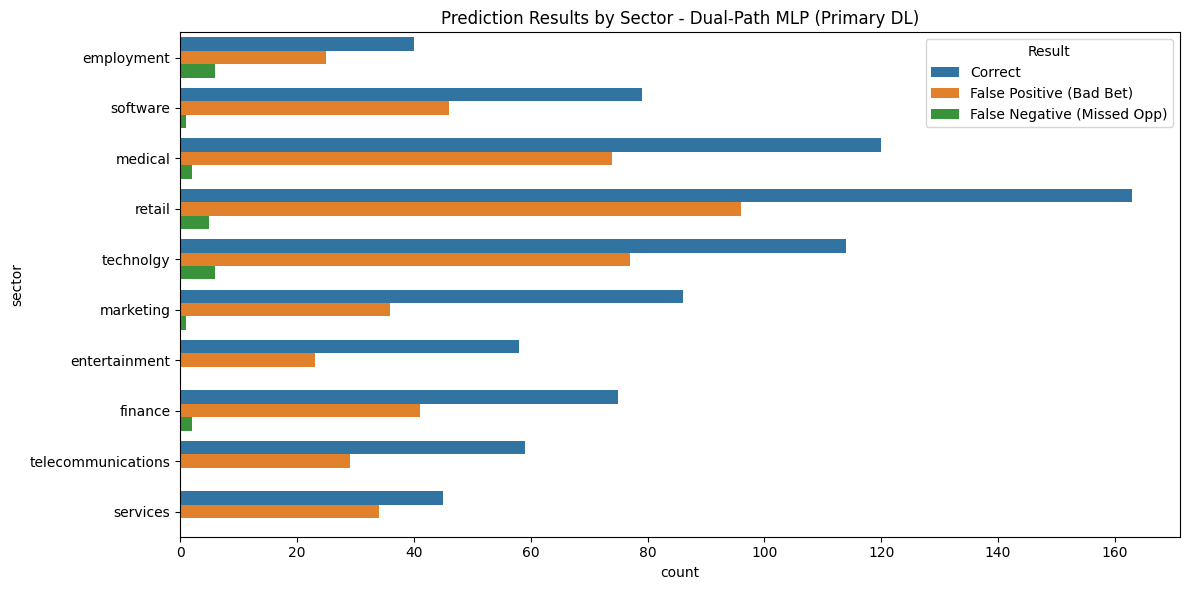

High-confidence False Positives: 10


,sector,product,sales_price,Probability
225,services,MG Special,55.0,0.908462
109,marketing,GTX Plus Basic,1096.0,0.804756
80,software,GTX Plus Basic,1096.0,0.856163
126,software,GTX Basic,550.0,0.815385
223,technolgy,GTXPro,1096.0,0.895631
279,technolgy,GTX Basic,550.0,0.888992
25,entertainment,GTX Plus Pro,5482.0,0.875559
14,telecommunications,MG Special,55.0,0.863876
254,medical,GTX Plus Pro,5482.0,0.817839
224,software,MG Special,55.0,0.921516


High-confidence False Negatives: 0


In [8]:
failure_df = X_test.copy()
failure_df['Actual'] = y_test.values
failure_df['Predicted'] = y_pred
failure_df['Probability'] = y_prob

failure_df['Result'] = 'Correct'
failure_df.loc[(failure_df['Actual'] == 0) & (failure_df['Predicted'] == 1), 'Result'] = 'False Positive (Bad Bet)'
failure_df.loc[(failure_df['Actual'] == 1) & (failure_df['Predicted'] == 0), 'Result'] = 'False Negative (Missed Opp)'

error_df = failure_df[failure_df['Result'] != 'Correct'].copy()
print(f'Total errors: {len(error_df)} / {len(failure_df)}')

if len(error_df) > 0:
    print('Error distribution by sector:')
    print(pd.crosstab(error_df['sector'], error_df['Result']).sort_index())

    print('Error distribution by product:')
    print(pd.crosstab(error_df['product'], error_df['Result']).sort_index())

    failure_df['price_band'] = pd.qcut(failure_df['sales_price'], q=4, duplicates='drop')
    print('Error distribution by pricing band:')
    print(pd.crosstab(failure_df['price_band'], failure_df['Result']))

plt.figure(figsize=(12, 6))
sns.countplot(data=failure_df, y='sector', hue='Result')
plt.title('Prediction Results by Sector - Dual-Path MLP (Primary DL)')
plt.tight_layout()
plt.savefig('../results/error_analysis_sector_dl_dual_path_mlp_primary.png', bbox_inches='tight')
plt.show()

high_conf_fp = failure_df[
    (failure_df['Result'] == 'False Positive (Bad Bet)') & (failure_df['Probability'] >= 0.80)
]
high_conf_fn = failure_df[
    (failure_df['Result'] == 'False Negative (Missed Opp)') & (failure_df['Probability'] <= 0.20)
]

high_conf_fp[['sector', 'product', 'sales_price', 'Probability']].to_csv(
    '../results/high_confidence_false_positives_dl_dual_path_mlp_primary.csv', index=False
)
high_conf_fn[['sector', 'product', 'sales_price', 'Probability']].to_csv(
    '../results/high_confidence_false_negatives_dl_dual_path_mlp_primary.csv', index=False
)

print(f'High-confidence False Positives: {len(high_conf_fp)}')
if len(high_conf_fp) > 0:
    display(high_conf_fp[['sector', 'product', 'sales_price', 'Probability']].head(10))

print(f'High-confidence False Negatives: {len(high_conf_fn)}')
if len(high_conf_fn) > 0:
    display(high_conf_fn[['sector', 'product', 'sales_price', 'Probability']].head(10))

## 7. SHAP Explainability for Technical Validation
To validate whether learned patterns align with business logic, we use SHAP on a **simplified explainability model** (linear model on processed features).

Rationale: this provides stable, global feature-attribution signals for tabular data while the primary DL model remains the performance model.

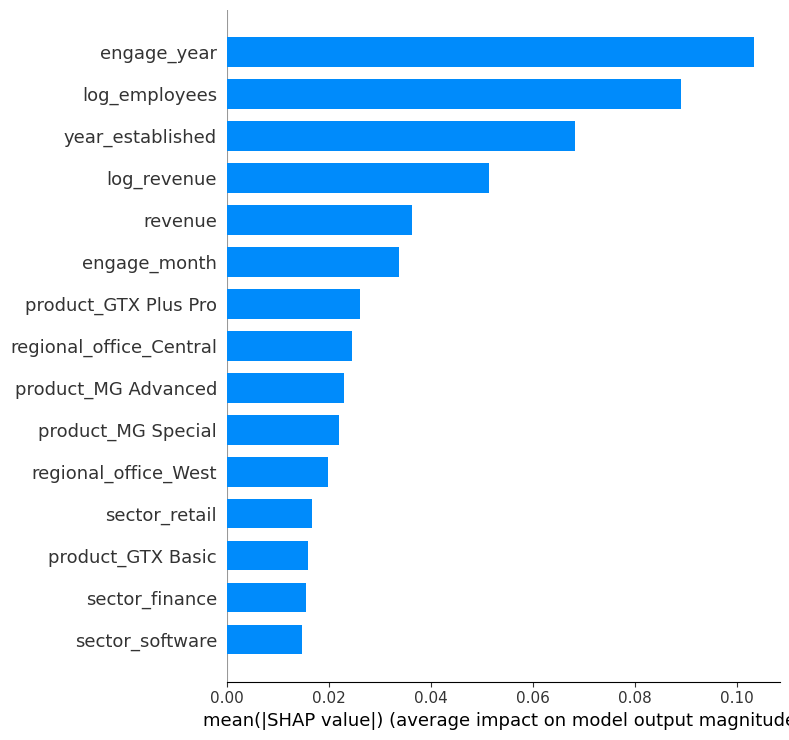

Top SHAP features (business alignment check):


,feature,mean_abs_shap
0,engage_year,0.103200
1,log_employees,0.088881
2,year_established,0.068113
3,log_revenue,0.051301
4,revenue,0.036379
5,engage_month,0.033701
6,product_GTX Plus Pro,0.026027
7,regional_office_Central,0.024506
8,product_MG Advanced,0.022913
9,product_MG Special,0.022070


In [9]:
if SHAP_AVAILABLE:
    explain_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    explain_model.fit(X_train_processed, y_train)

    background_size = min(200, X_train_processed.shape[0])
    sample_size = min(200, X_test_processed.shape[0])

    background = X_train_processed[:background_size]
    sample = X_test_processed[:sample_size]

    explainer = shap.LinearExplainer(explain_model, background, feature_names=feature_names)
    shap_values = explainer(sample)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values.values,
        sample,
        feature_names=feature_names,
        plot_type='bar',
        max_display=15,
        show=False,
    )
    plt.tight_layout()
    plt.savefig('../results/shap_feature_importance_tabular_simplified_linear.png', bbox_inches='tight')
    plt.show()

    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[-15:][::-1]

    shap_top_df = pd.DataFrame({
        'feature': [feature_names[i] for i in top_idx],
        'mean_abs_shap': mean_abs_shap[top_idx],
    })

    print('Top SHAP features (business alignment check):')
    display(shap_top_df)

    shap_top_df.to_csv('../results/shap_top_features_tabular_simplified_linear.csv', index=False)
else:
    print('SHAP is not installed in the environment. Install `shap` to run explainability.')

## 8. First-Principles Theory Notes
### Forward pass (dual-path)
Given numeric input $x_{num}$ and categorical input $x_{cat}$:

$$
h_{num} = 	ext{ReLU}(W_{num}x_{num} + b_{num}), \quad
h_{cat} = 	ext{ReLU}(W_{cat}x_{cat} + b_{cat})
$$

$$
h_{fuse} = [h_{num}; h_{cat}], \quad
h_1 = 	ext{ReLU}(W_1 h_{fuse} + b_1), \quad
h_2 = 	ext{ReLU}(W_2 h_1 + b_2)
$$

$$
\hat{y} = \sigma(W_o h_2 + b_o)
$$

### Loss behavior (binary cross-entropy + L2)

$$
\mathcal{L} = -
rac{1}{N}\sum_{i=1}^{N} \left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)
ight] + lpha\|W\|_2^2
$$

- BCE penalizes confident wrong predictions strongly.
- L2 regularization smooths effective complexity and improves generalization.

### Gradient descent intuition
- Gradients measure local sensitivity of loss to each parameter.
- Adam adapts per-parameter step sizes using momentum and squared-gradient history.
- Training seeks lower regions in a non-convex loss landscape, not guaranteed global minimum.

### Why ReLU works
- Sparse activation and stable gradients in positive region.
- Reduces vanishing-gradient severity compared to saturating nonlinearities.

### Bias-variance tradeoff
- Underfitting: high bias (model too simple).
- Overfitting: high variance (model too flexible).
- Regularization, validation, and architecture design balance this tradeoff.